# Cat and Dog Recognition — Self-Built ResNet-18

**Framework:** PyTorch.  
**Task:** Binary image classification — Cat vs. Dog.  
**Model:** Implementation from scratch, based on ResNet-18.  
**Reference:** https://doi.org/10.48550/arXiv.1512.03385  
**No pre-trained weights are used.**  

**Disclaimer: Project was partly assisted by Claude Sonnet 4.6, no subscription**

## Cell 1 — Architecture & Design Principles

### Background

Prior to ResNet, increasing network depth consistently degraded accuracy — not due to overfitting, but because gradients vanished during backpropagation through many layers. He et al. (2015) addressed this with **residual learning**: instead of learning a direct mapping `H(x)`, each block learns the residual `F(x) = H(x) - x` and adds back the input via a skip connection:

```
Output = F(x) + x
```

The `+1` term in the gradient `∂F(x)/∂x + 1` ensures a direct gradient path exists regardless of layer depth, structurally preventing vanishing gradients.

### BasicBlock

Based on BasicBlock (two 3×3 convolutions with a skip connection) used in ResNet-18, this project's BasicBlock follows similar structure:

```
Input
  ├──────────────────────┐
  ▼                      │
Conv(3×3) → BN → ReLU    |
  │                      │ Skip
Conv(3×3) → BN           │
  │                      │
  + ◄────────────────────┘
  │
ReLU
```

When a block downsamples (stride=2) or changes channel count, the skip connection uses a 1×1 conv (**projection shortcut**) to match dimensions before addition.

### Overall Architecture

```
Input (224×224×3)
    │
Stem: Conv(7×7, 64, stride=2) → BN → ReLU → MaxPool(3×3, stride=2) → 56×56×64
    │
Layer 1: BasicBlock × 2  (64 channels,  stride=1) → 56×56×64
Layer 2: BasicBlock × 2  (128 channels, stride=2) → 28×28×128
Layer 3: BasicBlock × 2  (256 channels, stride=2) → 14×14×256
Layer 4: BasicBlock × 2  (512 channels, stride=2) →  7×7×512
    │
Global Average Pooling → 512
    │
FC(512 → 2)
```

### Design Decisions

| Decision | Choice |
|---|---|
| Block type | BasicBlock (2× 3×3 conv): Sufficient depth for this task |
| Depth | 18 layers (4 stages × 2 blocks × 2 convs + stem + FC) |
| Downsampling | stride=2 in first block of each stage; projection shortcut on skip path |
| Spatial aggregation | Global Average Pooling: Avoids large FC layers |
| Output | FC(512→2) with CrossEntropyLoss: Standard binary classification |
| Weight init | Kaiming Normal (He et al.): Designed for ReLU networks |

## Cell 2 — Setup & Imports

In [3]:
import os, time, copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.7.0


## Cell 3 — Data Loading & Augmentation

In [4]:
DATA_DIR = "./cats_and_dogs"
IMG_SIZE = 224
BATCH    = 32
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"),      transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "validation"), transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),       transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
print(f"Classes : {CLASS_NAMES}")
print(f"Train   : {len(train_ds):,} images")
print(f"Val     : {len(val_ds):,} images")
print(f"Test    : {len(test_ds):,} images")

Classes : ['cats', 'dogs']
Train   : 2,000 images
Val     : 1,000 images
Test    : 1,000 images


## Cell 4 — Visualise Sample Training Images

c:\Users\v303\anaconda3\envs\hsi-torch\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


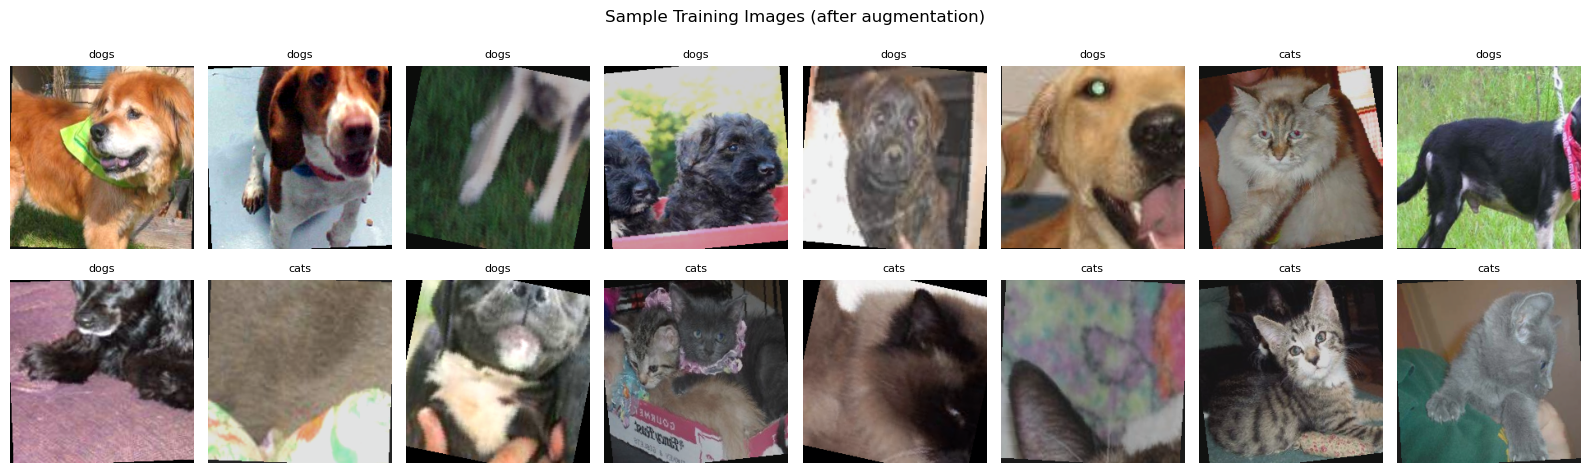

In [5]:
def imshow(tensor, title=None):
    img = tensor.numpy().transpose(1, 2, 0)
    img = (img * STD + MEAN).clip(0, 1)
    plt.imshow(img)
    if title: plt.title(title, fontsize=8)
    plt.axis("off")

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)
    imshow(images[i], CLASS_NAMES[labels[i]])
plt.suptitle("Sample Training Images (after augmentation)", fontsize=12)
plt.tight_layout()
plt.show()

## Cell 5 — Model Definition

In [6]:
class BasicBlock(nn.Module):
    """
    ResNet BasicBlock: two 3×3 convolutions with a skip connection.
    A projection shortcut (1×1 conv) is used when spatial dimensions
    or channel counts change between input and output.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.residual = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        # Projection shortcut: align dimensions when stride>1 or channels change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.residual(x) + self.shortcut(x))


class ResNet18(nn.Module):
    """
    ResNet-18 built from scratch following He et al. (2015).
    4 stages of BasicBlocks, each stage doubling channels and
    halving spatial resolution (except Stage 1).
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )  # 224×224 → 56×56

        # Residual stages
        self.layer1 = self._make_layer( 64,  64, stride=1)  # 56×56
        self.layer2 = self._make_layer( 64, 128, stride=2)  # 28×28
        self.layer3 = self._make_layer(128, 256, stride=2)  # 14×14
        self.layer4 = self._make_layer(256, 512, stride=2)  #  7×7

        # Classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(512, num_classes)

        # Kaiming initialisation for ReLU networks
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_ch, out_ch, stride):
        """One stage: first block may downsample, second block is identity."""
        return nn.Sequential(
            BasicBlock(in_ch, out_ch, stride=stride),
            BasicBlock(out_ch, out_ch, stride=1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)


model = ResNet18(num_classes=2).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:>12,}")
print(f"Trainable parameters: {trainable:>12,}  <- all trained from scratch")

Total parameters    :   11,177,538
Trainable parameters:   11,177,538  <- all trained from scratch


## Cell 6 — Training Configuration

In [34]:
EPOCHS = 50
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-5
)  # monitors val_acc; halves LR if no improvement for 2 epochs

print(f"Optimiser : Adam (lr={LR}, weight_decay=1e-4)")
# print(f"Optimiser : SGD (lr={LR}, weight_decay=1e-4)")
print(f"Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=2, min_lr=1e-5)")
print(f"Epochs    : {EPOCHS}")

Optimiser : Adam (lr=0.001, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=2, min_lr=1e-5)
Epochs    : 50


## Cell 7 — Training Loop

In [35]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc  = 0.0
best_val_loss = float("inf")
best_weights  = copy.deepcopy(model.state_dict())

# Early stopping
early_stop_patience = 5
epochs_no_improve   = 0

t0 = time.time()

for epoch in range(EPOCHS):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    run_loss, run_correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        run_loss    += loss.item() * inputs.size(0)
        run_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = run_loss    / len(train_ds)
    train_acc  = run_correct / len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            v_loss    += criterion(outputs, labels).item() * inputs.size(0)
            v_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = v_loss    / len(val_ds)
    val_acc  = v_correct / len(val_ds)

    scheduler.step(val_acc)

    # Track best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        best_weights  = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} "
          f"| Train Loss {train_loss:.4f}  Acc {train_acc:.4f} "
          f"| Val Loss {val_loss:.4f}  Acc {val_acc:.4f}")

    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}.")
        break

model.load_state_dict(best_weights)
elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.1f}s")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 01/50 | Train Loss 0.5931  Acc 0.6830 | Val Loss 0.5746  Acc 0.7160
Epoch 02/50 | Train Loss 0.5802  Acc 0.6955 | Val Loss 0.5644  Acc 0.7600
Epoch 03/50 | Train Loss 0.5861  Acc 0.6880 | Val Loss 0.5353  Acc 0.7670
Epoch 04/50 | Train Loss 0.5641  Acc 0.7130 | Val Loss 0.5250  Acc 0.7510
Epoch 05/50 | Train Loss 0.5750  Acc 0.7020 | Val Loss 0.5275  Acc 0.7410
Epoch 06/50 | Train Loss 0.5684  Acc 0.7030 | Val Loss 0.5304  Acc 0.7730
Epoch 07/50 | Train Loss 0.5585  Acc 0.7010 | Val Loss 0.5290  Acc 0.7610
Epoch 08/50 | Train Loss 0.5626  Acc 0.7095 | Val Loss 0.4984  Acc 0.7630
Epoch 09/50 | Train Loss 0.5415  Acc 0.7265 | Val Loss 0.6076  Acc 0.7320
Epoch 10/50 | Train Loss 0.5413  Acc 0.7285 | Val Loss 0.4741  Acc 0.7920
Epoch 11/50 | Train Loss 0.5161  Acc 0.7470 | Val Loss 0.4655  Acc 0.7830
Epoch 12/50 | Train Loss 0.5222  Acc 0.7400 | Val Loss 0.4375  Acc 0.7980
Epoch 13/50 | Train Loss 0.5224  Acc 0.7260 | Val Loss 0.4645  Acc 0.7770
Epoch 14/50 | Train Loss 0.5144  Acc 0

## Cell 8 — Loss & Accuracy Curves

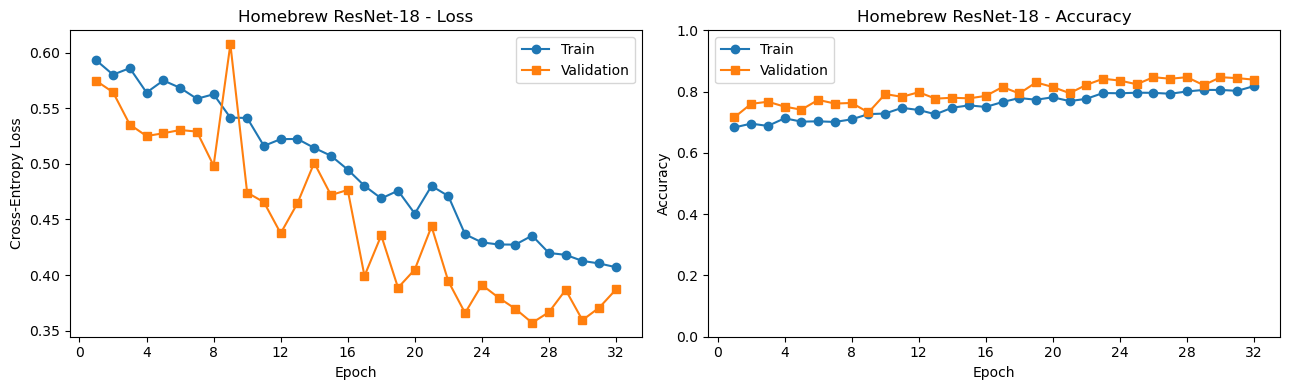

In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_ran, history["train_loss"], marker="o", label="Train")
ax1.plot(epochs_ran, history["val_loss"],   marker="s", label="Validation")
ax1.set_title("Homebrew ResNet-18; Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2.plot(epochs_ran, history["train_acc"], marker="o", label="Train")
ax2.plot(epochs_ran, history["val_acc"],   marker="s", label="Validation")
ax2.set_title("Homebrew ResNet-18; Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1); ax2.legend()
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("resnet18_scratch_curves.png", dpi=120)
plt.show()

## Cell 9 — Test Set Evaluation

In [37]:
model.eval()
test_correct = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        preds = model(inputs).argmax(1)
        test_correct += (preds == labels).sum().item()

test_acc = test_correct / len(test_ds)

print("-" * 35)
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test Samples  : {len(test_ds):,}")
print(f"  Correct       : {test_correct:,}")
print(f"  Wrong         : {len(test_ds) - test_correct:,}")
print("-" * 35)

-----------------------------------
  Test Accuracy : 0.8290 (82.90%)
  Test Samples  : 1,000
  Correct       : 829
  Wrong         : 171
-----------------------------------


## Cell 10 — Prediction Visualisation

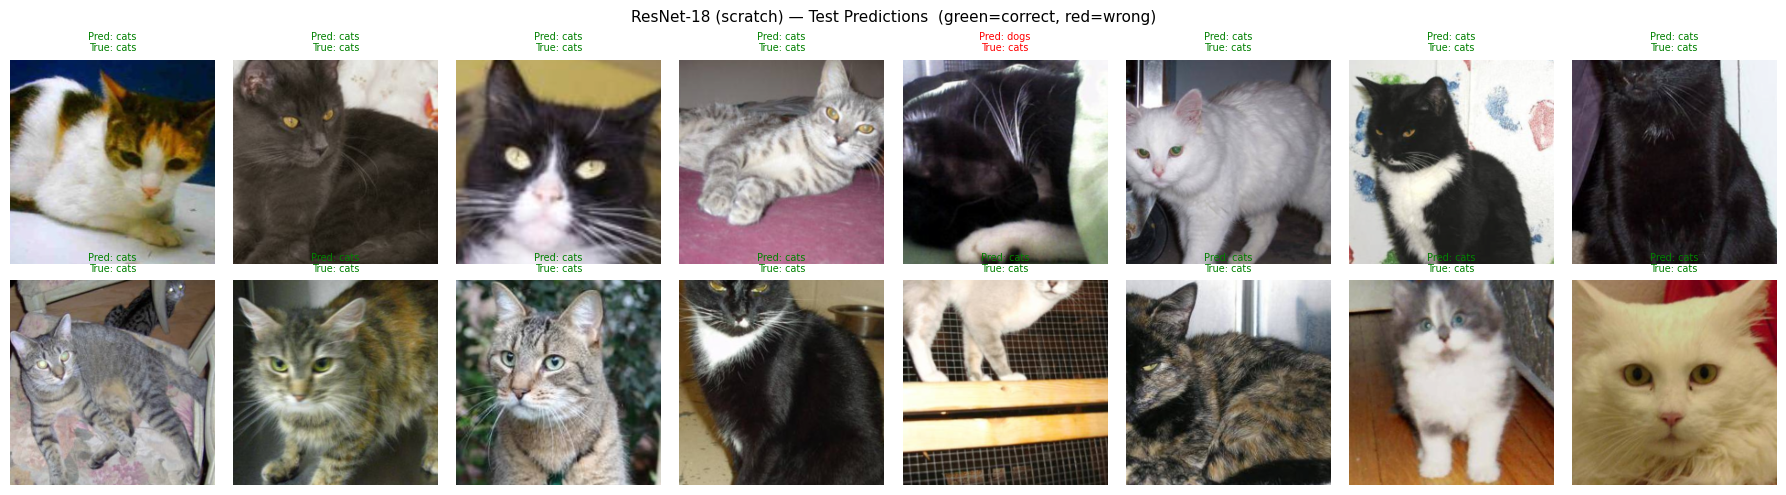

In [38]:
model.eval()
images, labels = next(iter(test_loader))

with torch.no_grad():
    preds = model(images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * STD + MEAN).clip(0, 1)
    ax.imshow(img)
    colour = "green" if preds[i] == labels[i] else "red"
    ax.set_title(f"Pred: {CLASS_NAMES[preds[i]]}\nTrue: {CLASS_NAMES[labels[i]]}",
                 color=colour, fontsize=7)
    ax.axis("off")

plt.suptitle("ResNet-18 (scratch) — Test Predictions  (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.show()

## Cell 11 — Conclusion

### Architecture Summary

| Component | Detail |
|---|---|
| Stem | Conv(7×7, stride=2) → BN → ReLU → MaxPool — rapid spatial reduction |
| Stages 1–4 | 2× BasicBlock each; channels double (64→128→256→512), spatial dims halve |
| Skip connections | Identity shortcut (same dims) or projection shortcut (1×1 conv, stride=2) |
| Aggregation | Global Average Pooling — spatial invariance, no large FC layers |
| Classifier | Single FC(512→2) |
| Weight init | Kaiming Normal — accounts for ReLU's effect on variance |
| Parameters | ~11.2M, all trained from scratch |

### Comparison with Hw 3 (EfficientNet-B0, pre-trained)

| | ResNet-18 (Hw 4) | EfficientNet-B0 (Hw 3) |
|---|---|---|
| Weights | Random initialisation | ImageNet pre-trained |
| Parameters trained | ~11.2M | ~2,562 (head only) |
| Conv type | Standard 3×3 | Depthwise separable |
| Channel attention | None | Squeeze-and-Excitation |
| Best val accuracy | 84.2% | 97.0% |
| Test accuracy | 82.9% | 97.0% |
| Epochs to converge | 23 | ~8 |
| Training time | 2,778s (due to PyTorch faulty installation) | 527s |

The accuracy gap quantifies the contribution of pre-training on 1.28M ImageNet images. The residual learning principle is shared between both models — EfficientNet's MBConv blocks include skip connections inherited from the same He et al. paper implemented here from scratch.